1. Improve the model by using interpolation smoothing with the "Stupid Backoff" method (Brants et al., 2007).

    Two links that i think we can reference:

    [Large Language Models in Machine Translation](https://aclanthology.org/D07-1090.pdf)

    [N-gram Language Models (Speech and Language Processing Book from Stanford)](https://web.stanford.edu/~jurafsky/slp3/3.pdf)

2. Compare with the results from In Class Exercise.

3. Use the newly built model to generate the next words for a given word sequence.

4. Combine with a function that calculates the distance between words to predict the correct word for a misspelled word position. (from difflib import get_close_matches)

# Extracting txt file

Notes on the url link

Our drive links have the format like this: "https://drive.google.com/file/d/extracted_id/view?usp=sharing"

Keep that extracted id and paste in this link: "https://docs.google.com/uc?export=download&id=extracted_id"

In [1]:
import requests

txt_url = "https://docs.google.com/uc?export=download&id=14jsTimd626t7Vm9b-Bsvv6jq4UxbNVHN"
response = requests.get(txt_url)
txt_content = response.text

print(txt_content[:1000])

Thank you so much, Chris. And it's truly a great honor to have the opportunity to come to this stage twice; I'm extremely grateful. I have been blown away by this conference, and I want to thank all of you for the many nice comments about what I had to say the other night. And I say that sincerely, partly because (Mock sob) I need that. (Laughter) Put yourselves in my position. (Laughter) I flew on Air Force Two for eight years. (Laughter) Now I have to take off my shoes or boots to get on an airplane! (Laughter) (Applause) I'll tell you one quick story to illustrate what that's been like for me. (Laughter) It's a true story — every bit of this is true. Soon after Tipper and I left the — (Mock sob) White House — (Laughter) we were driving from our home in Nashville to a little farm we have 50 miles east of Nashville. Driving ourselves. (Laughter) I know it sounds like a little thing to you, but — (Laughter) I looked in the rear-view mirror and all of a sudden it just hit me. There was 

# Building language model using "Stupid Backoff" smoothing method

## Building language models with 1-gram, 2-gram, and 3-gram

In [2]:
from collections import Counter
import nltk
from nltk import word_tokenize, sent_tokenize
from nltk import ngrams
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
def build_LMs(string):
  sentences = sent_tokenize(string)
  num_sentence = len(sentences)

  LM_1gram = Counter()
  LM_2gram = Counter()
  LM_3gram = Counter()

  for sentence in sentences:
    words = word_tokenize(sentence.lower())

    # Build 1-gram
    LM_1gram.update(words)

    # Build 2-gram
    words_bigram = ["<s>"] + words + ["</s>"]
    bigrams = list(ngrams(words_bigram, n = 2))
    LM_2gram.update(bigrams)

    # Build 3-gram
    words_trigram = ["<s>", "<s>"] + words + ["</s>"]
    trigram = list(ngrams(words_trigram, n = 3))
    LM_3gram.update(trigram)

  return num_sentence, LM_1gram, LM_2gram, LM_3gram


In [4]:
num_sentence, LM_1gram, LM_2gram, LM_3gram = build_LMs(txt_content)

In [5]:
LM_1gram.most_common(20)

[(',', 491444),
 ('.', 403920),
 ('the', 336175),
 ('and', 240239),
 ('to', 210344),
 ('of', 185683),
 ('a', 170522),
 ('that', 152589),
 ('i', 130643),
 ('in', 126071),
 ('it', 115742),
 ('we', 108805),
 ('you', 108370),
 ('is', 100182),
 ("'s", 85317),
 ('this', 74899),
 ('so', 56855),
 ('they', 52636),
 ('for', 51320),
 ('was', 50850)]

In [6]:
LM_2gram.most_common(20)

[(('.', '</s>'), 388932),
 ((',', 'and'), 62197),
 (('<s>', 'and'), 60386),
 (('of', 'the'), 33806),
 (('it', "'s"), 32902),
 (('?', '</s>'), 32096),
 (('in', 'the'), 31721),
 (('<s>', 'so'), 30014),
 (('<s>', 'i'), 28692),
 ((',', 'i'), 23344),
 (('<s>', 'it'), 22816),
 ((',', 'the'), 21619),
 (('<s>', '('), 20566),
 (('<s>', 'but'), 20560),
 ((',', 'but'), 19828),
 (("''", '</s>'), 19798),
 (('<s>', 'we'), 19096),
 ((',', 'we'), 18050),
 (('<s>', 'the'), 17956),
 (('and', 'i'), 17049)]

In [7]:
LM_3gram.most_common(20)

[(('<s>', '<s>', 'and'), 60386),
 (('<s>', '<s>', 'so'), 30014),
 (('<s>', '<s>', 'i'), 28692),
 (('<s>', '<s>', 'it'), 22816),
 (('<s>', '<s>', '('), 20566),
 (('<s>', '<s>', 'but'), 20560),
 (('<s>', '<s>', 'we'), 19096),
 (('<s>', '<s>', 'the'), 17956),
 (('.', "''", '</s>'), 14378),
 (('(', 'laughter', ')'), 13952),
 (('<s>', '(', 'laughter'), 12075),
 (('<s>', '<s>', 'this'), 11689),
 (('<s>', 'it', "'s"), 11358),
 (('<s>', '<s>', 'you'), 10431),
 (('<s>', '<s>', 'they'), 10364),
 (('<s>', '<s>', 'now'), 9762),
 (('<s>', '<s>', 'in'), 8202),
 (('it', '.', '</s>'), 7838),
 (('<s>', '<s>', 'that'), 7671),
 (('(', 'applause', ')'), 7536)]

## "Stupid Backoff" smoothing method

In [8]:
# Hyper-parameter
lambda_1 = 0.4
lambda_2 = 0.4

### 1-gram

In [9]:
def calculate_P_1gram(word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_1gram[word_i] + 1) / (len(LM_1gram) + LM_1gram.total())


  ########## Back off method ##########

  # Check count
  if LM_1gram[word_i] != 0:
    return LM_1gram[word_i] / LM_1gram.total()
  else:
    return 1 / LM_1gram.total() # I assigned this to prevent unseen unigram

In [10]:
def test_string_1gram(test_word):
  test_word = test_word.lower()
  print(f"Number of occurence of the string \"{test_word}\" in the corpus: {LM_1gram[test_word]}")
  P_test_word = calculate_P_1gram(test_word)
  print(f"Smoothed probability of the word \"{test_word}\" using Laplace smoothing: {P_test_word:.4e}")

In [11]:
# Out-of-distribution word
test_string_1gram("bruh")

# Common word
test_string_1gram("I")

Number of occurence of the string "bruh" in the corpus: 0
Smoothed probability of the word "bruh" using Laplace smoothing: 1.1801e-07
Number of occurence of the string "i" in the corpus: 130643
Smoothed probability of the word "i" using Laplace smoothing: 1.5417e-02


### 2-gram

In [12]:
def calculate_P_2gram(word_i1, word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_2gram[(word_i1, word_i)] + 1) / (LM_1gram[word_i1] + len(LM_1gram))

  ########## Back off method ##########

  # Check count
  if LM_2gram[(word_i1, word_i)] != 0:
    # Handle missing leading start symbol
    if word_i1 == "<s>":
      return LM_2gram[(word_i1, word_i)] / num_sentence
    else:
      return LM_2gram[(word_i1, word_i)] / LM_1gram[word_i1]
  else:
    return lambda_1 * calculate_P_1gram(word_i)

In [13]:
def test_string_2gram(test_string):
  test_word_i1, test_word_i = word_tokenize(test_string.lower())

  print(f"Number of occurence of the string \"{test_string}\" in the corpus: {LM_2gram[(test_word_i1, test_word_i)]}")
  P_test_word = calculate_P_2gram(test_word_i1, test_word_i)
  print(f"Smoothed probability of the word \"{test_string}\" using Laplace smoothing: {P_test_word:.4e}")

In [14]:
# Out-of-distribution
test_string_2gram("I her")

# Common
test_string_2gram("I'm")

Number of occurence of the string "I her" in the corpus: 0
Smoothed probability of the word "I her" using Laplace smoothing: 4.0129e-04
Number of occurence of the string "I'm" in the corpus: 13348
Smoothed probability of the word "I'm" using Laplace smoothing: 1.0217e-01


### 3-gram

In [15]:
def calculate_P_3gram(word_i2, word_i1, word_i, smoothing_type = "Backoff"):
  if smoothing_type == "Laplace":
    return (LM_3gram[(word_i2, word_i1, word_i)] + 1) / (LM_2gram[(word_i2, word_i1)] + len(LM_1gram))

  ########## Back off method ##########

  # Check count
  if LM_3gram[(word_i2, word_i1, word_i)] != 0:
    # Handle missing leading start symbol
    if word_i1 == "<s>" and word_i2 == "<s>":
      return LM_3gram[(word_i2, word_i1, word_i)] / num_sentence
    else:
      return LM_3gram[(word_i2, word_i1, word_i)] / LM_2gram[(word_i2, word_i1)]
  else:
    return lambda_2 * calculate_P_2gram(word_i1, word_i)

In [16]:
def test_string_3gram(test_string):
  test_word_i2, test_word_i1, test_word_i = word_tokenize(test_string.lower())

  print(f"Number of occurence of the string \"{test_string}\" in the corpus: {LM_3gram[(test_word_i2, test_word_i1, test_word_i)]}")
  P_test_word = calculate_P_3gram(test_word_i2, test_word_i1, test_word_i)
  print(f"Smoothed probability of the word \"{test_string}\" using Laplace smoothing: {P_test_word:.4e}")

In [17]:
# Out-of-distribution
test_string_3gram("I'm handsome")

# Common
test_string_3gram("I'm happy")

Number of occurence of the string "I'm handsome" in the corpus: 0
Smoothed probability of the word "I'm handsome" using Laplace smoothing: 6.9863e-07
Number of occurence of the string "I'm happy" in the corpus: 75
Smoothed probability of the word "I'm happy" using Laplace smoothing: 5.6188e-03


# Comparing with the results from In Class Exercise.

## Process each sentence methods

In [18]:
def process_sentence(sentence, type_n):
  tokens = word_tokenize(sentence.lower())

  if type_n == 2:
    tokens = ['<s>'] + tokens + ['</s>']
  elif type_n == 3:
    tokens = ['<s>', '<s>'] + tokens + ['</s>']

  return tokens

In [19]:
def sentence_prob(sentence, type_n, smoothing_type = "Backoff"):

  # Unsupported
  if type_n not in [1, 2, 3]:
    print(f"Do not support this type of language model: {type_n}-gram ! Retry :)")
    return 0.0

  # Process the sentence
  tokens = process_sentence(sentence, type_n)
  n_gram_list = list(ngrams(tokens, n = type_n))

  # Calculate the prob
  P = 1.0

  if type_n == 1:
    for n_gram in n_gram_list:
      P *= calculate_P_1gram(n_gram[0], smoothing_type)
  elif type_n == 2:
    for n_gram in n_gram_list:
      P *= calculate_P_2gram(n_gram[0], n_gram[1], smoothing_type)
  else:
    for n_gram in n_gram_list:
      P *= calculate_P_3gram(n_gram[0], n_gram[1], n_gram[2], smoothing_type)
  return P

In [20]:
def test_sentence_prob(sentence, smoothing_type = "Backoff"):
  P_1 = sentence_prob(sentence, 1, smoothing_type)
  P_2 = sentence_prob(sentence, 2, smoothing_type)
  P_3 = sentence_prob(sentence, 3, smoothing_type)
  return P_1, P_2, P_3

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_sentence_probabilities(sentence, backoff_probs, laplace_probs):
  labels = ['1-gram', '2-gram', '3-gram']
  x = range(len(labels))

  df = pd.DataFrame({
      'N-gram': labels,
      'Backoff': backoff_probs,
      'Laplace': laplace_probs
  })

  fig, ax = plt.subplots(figsize=(6, 4))

  ax.plot(x, df['Backoff'], marker='o', linestyle='-', label='Backoff', color='skyblue')
  ax.plot(x, df['Laplace'], marker='x', linestyle='--', label='Laplace', color='lightcoral')

  ax.set_ylabel('Log Probability (base 10)')
  ax.set_title(f'"{sentence}"')
  ax.set_xticks(x)
  ax.set_xticklabels(labels)
  ax.legend()
  ax.set_yscale('log') # For better visualization of small prob

  plt.tight_layout()
  plt.show()

## Test all sentences

In [22]:
def test_all_sentences():
  sentences = {
      "Okay, on the count of three, you're going to go.", # Sentence from corpus
      "Thank you very much.",                             # Common sentence
      "A sentence that is not in corpus.",                # Not in corpus
      "He is a husband, a dad, and a superman.",           # New meaningful sentence
      "The boat was like a pea floating in a great bowl of blue soup." # Long meaningful sentence
  }

  for sentence in sentences:

    # Backoff
    P_backoff_1, P_backoff_2, P_backoff_3 = test_sentence_prob(sentence, "Backoff")
    backoff_probs = [P_backoff_1, P_backoff_2, P_backoff_3]

    # Laplace
    P_laplace_1, P_laplace_2, P_laplace_3 = test_sentence_prob(sentence, "Laplace")
    laplace_probs = [P_laplace_1, P_laplace_2, P_laplace_3]

    # Plot results
    plot_sentence_probabilities(sentence, backoff_probs, laplace_probs)

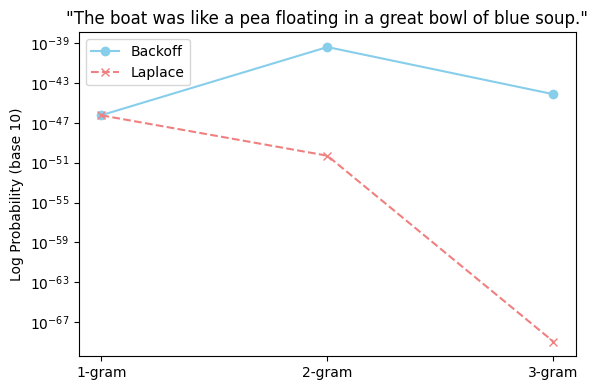

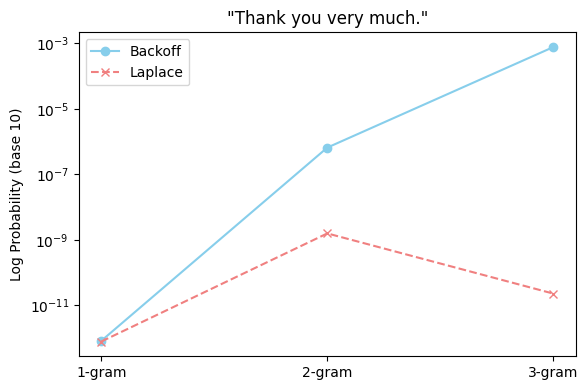

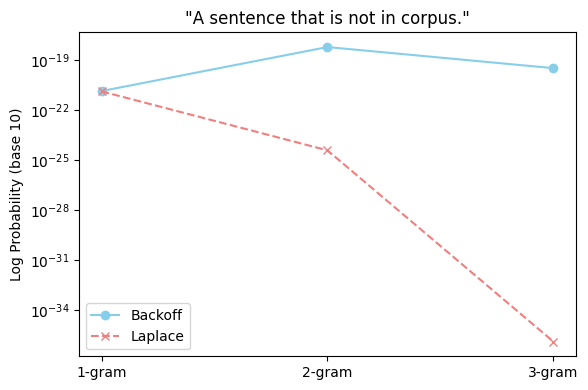

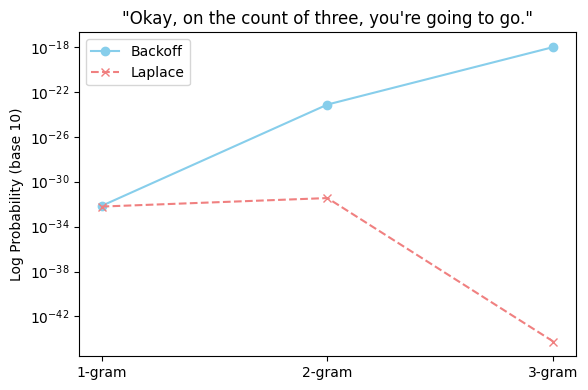

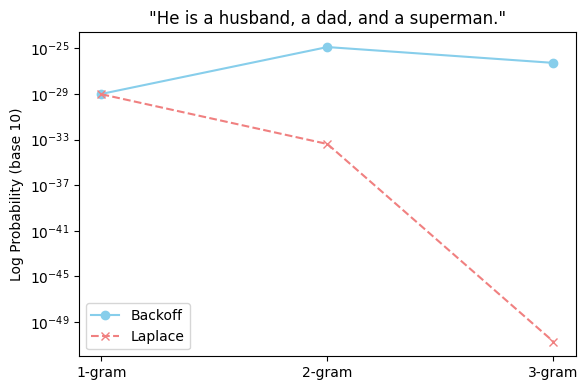

In [23]:
test_all_sentences()

## Some thought

As i considered, those two different smoothing methods "Backoff" and "Laplace" have different behaviors towards all types of sentences. While "Backoff" method observed increasing probabilities for higher-order n-grams, the "Laplace" method mostly observed decreasing probabilities.

They have same starting points, as we expected. Because, they use the same formula for calculing the probability for sentence using unigram.

"He is a husband, a dad, and a superman" is the only sentence that observed the slightly rising down in probability in "Backoff" method. As we think, this is a whole new sentence.

# Generating the next words for a given word sequence.

In [24]:
def get_potential_next_words(word_i2, word_i1):
  potential_next_words = []

  # Trigram
  for (w2, w1, w0) in LM_3gram.keys():
    if (w2, w1) == (word_i2, word_i1):
      potential_next_words.append(w0)

  # Bigram if not trigram
  if not potential_next_words:
    for (w1, w0) in LM_2gram.keys():
      if w1 == word_i1:
        potential_next_words.append(w0)

  # Unigram
  if not potential_next_words:
    potential_next_words = list(LM_1gram.keys())

  return potential_next_words

In [25]:
import random
import string

def gen_word(word_i2, word_i1, top_k):
  ### Switch to next sentence ###
  if word_i1 == "</s>":
    return "<s>"
  if word_i1 == ".":
    return "</s>"

  ### Normal flow ###

  potential_next_words = get_potential_next_words(word_i2, word_i1)

  words_probability = []

  for word in potential_next_words:
    words_probability.append((word, calculate_P_3gram(word_i2, word_i1, word)))

  words_probability.sort(key = lambda x: x[1], reverse = True)
  top_k_words = [word for word in words_probability[:top_k]]

  if top_k_words:
    word = random.choice(top_k_words)[0]
    # if word in string.punctuation:
    #   word = random.choice(top_k_words)[0]
    return word
  else:
    return "."

In [26]:
def gen_words(given_sentence, top_k = 5, max_len = 50):
  tokens = word_tokenize(given_sentence.lower())

  word_i2, word_i1 = None, None
  if len(tokens) >= 2:
    word_i2, word_i1 = tokens[-2], tokens[-1]
  elif len(tokens) == 1:
    word_i2, word_i1 = "<s>", tokens[-1]
  else:
    word_i2, word_i1 = "<s>", "<s>"

  predicted_tokens = []
  for i in range(max_len):
    predicted_tokens.append(gen_word(word_i2, word_i1, top_k))
    word_i2 = word_i1
    word_i1 = predicted_tokens[-1]

  return " ".join(predicted_tokens)

In [29]:
given_sentence = "Hey,"
print(given_sentence + " " + gen_words(given_sentence, top_k = 1, max_len = 30))

given_sentence = "I have a"
print(given_sentence + " " + gen_words(given_sentence, top_k = 3, max_len = 30))

given_sentence = "Thank you very"
print(given_sentence + " " + gen_words(given_sentence, top_k = 5, max_len = 30))

given_sentence = "This is a very good"
print(given_sentence + " " + gen_words(given_sentence, top_k = 10, max_len = 30))

given_sentence = "I'm very proud of myself"
print(given_sentence + " " + gen_words(given_sentence, top_k = 20, max_len = 30))

Hey, i 'm going to be a little bit of a sudden , you know , i 'm going to be a little bit of a sudden , you know ,
I have a lot more about that . </s> <s> and the reason i say that , and it is , `` what do you want . </s> <s> so we have to
Thank you very far from perfect , and i think the answer was : what are these little , and they do . </s> <s> so we 're all here , and the
This is a very good . </s> <s> but there were other passengers . </s> <s> we were in their lives for a few minutes later per piece . </s> <s> so what you can
I'm very proud of myself . </s> <s> that means to a hospital . </s> <s> that day is shredded to bits by the brain and cause a disruption in brain sciences , they did


# Calculating the distance between words to predict the correct word for a misspelled word position

As i researched, they suggest words by calculating the possibilities using this formula

    2 * matches / Total characters in misspelled and suggestion one
Then, take the curoff as the threshold :v


In [30]:
from difflib import get_close_matches

def correct_word_of(misspelled_word, max_word_return = 5, cutoff = 0.6):
  misspelled_word = misspelled_word.lower()
  vocab = list(LM_1gram.keys())
  close_matches = get_close_matches(misspelled_word, vocab, max_word_return, cutoff)
  return close_matches

In [31]:
print(f"Suggestions for 'hapyy': {correct_word_of('hapyy')}")
print(f"Suggestions for 'lenguage': {correct_word_of('lenguage')}")
print(f"Suggestions for 'moddel': {correct_word_of('moddel')}")
print(f"Suggestions for 'compary': {correct_word_of('compary')}")


Suggestions for 'hapyy': ['harpy', 'happy', 'hay', 'hap', 'unhappy']
Suggestions for 'lenguage': ['language', 'engage', 'languages', 'engages', 'engaged']
Suggestions for 'moddel': ['model', 'models', 'odde', 'mode', 'remodel']
Suggestions for 'compary': ['comporary', 'compare', 'company', 'copay', 'comparably']
